In [1]:
import xarray as xr

file_path = "../data/raw/Currents/Currents.nc"

ds = xr.open_dataset(file_path)

print(ds)

<xarray.Dataset> Size: 234MB
Dimensions:    (time: 609, depth: 1, latitude: 100, longitude: 240)
Coordinates:
  * time       (time) datetime64[ns] 5kB 2025-01-01 2025-01-02 ... 2026-09-01
  * depth      (depth) int16 2B 0
  * latitude   (latitude) float32 400B 5.125 5.375 5.625 ... 29.38 29.62 29.88
  * longitude  (longitude) float32 960B 45.12 45.38 45.62 ... 104.4 104.6 104.9
Data variables:
    uo         (time, depth, latitude, longitude) float64 117MB ...
    vo         (time, depth, latitude, longitude) float64 117MB ...
Attributes: (12/18)
    Conventions:               CF-1.6
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-10-26 09:30:42
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east
    geospatial_vertical_max:   0.0
    ...                        ...
    lon_min:                   -179.875
    lon_res:                   0.25
    product_version:           4.0
    references:      

In [2]:
print(ds.dims)
print(ds.coords)
print(ds.data_vars)

FrozenMappingWarningOnValuesAccess({'time': 609, 'depth': 1, 'latitude': 100, 'longitude': 240})
Coordinates:
  * time       (time) datetime64[ns] 5kB 2025-01-01 2025-01-02 ... 2026-09-01
  * depth      (depth) int16 2B 0
  * latitude   (latitude) float32 400B 5.125 5.375 5.625 ... 29.38 29.62 29.88
  * longitude  (longitude) float32 960B 45.12 45.38 45.62 ... 104.4 104.6 104.9
Data variables:
    uo       (time, depth, latitude, longitude) float64 117MB ...
    vo       (time, depth, latitude, longitude) float64 117MB ...


In [3]:
print(ds)

<xarray.Dataset> Size: 234MB
Dimensions:    (time: 609, depth: 1, latitude: 100, longitude: 240)
Coordinates:
  * time       (time) datetime64[ns] 5kB 2025-01-01 2025-01-02 ... 2026-09-01
  * depth      (depth) int16 2B 0
  * latitude   (latitude) float32 400B 5.125 5.375 5.625 ... 29.38 29.62 29.88
  * longitude  (longitude) float32 960B 45.12 45.38 45.62 ... 104.4 104.6 104.9
Data variables:
    uo         (time, depth, latitude, longitude) float64 117MB ...
    vo         (time, depth, latitude, longitude) float64 117MB ...
Attributes: (12/18)
    Conventions:               CF-1.6
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-10-26 09:30:42
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east
    geospatial_vertical_max:   0.0
    ...                        ...
    lon_min:                   -179.875
    lon_res:                   0.25
    product_version:           4.0
    references:      

In [4]:
print(ds.data_vars)

Data variables:
    uo       (time, depth, latitude, longitude) float64 117MB ...
    vo       (time, depth, latitude, longitude) float64 117MB ...


In [5]:
for var in ds.data_vars:
    print("\n================================")
    print("VARIABLE:", var)
    print("================================")
    print("Attributes:")
    print(ds[var].attrs)
    print("\nEncoding:")
    print(ds[var].encoding)


VARIABLE: uo
Attributes:
{'grid_mapping': 'crs', 'long_name': 'Absolute geostrophic velocity + depth Ekman + tide velocity: zonal component', 'standard_name': 'eastward_sea_water_velocity', 'units': 'm/s'}

Encoding:
{'dtype': dtype('int16'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contiguous': True, 'chunksizes': None, 'source': 'c:\\OceanF\\data\\raw\\Currents\\Currents.nc', 'original_shape': (609, 1, 100, 240), '_FillValue': np.int16(32767), 'scale_factor': np.float64(0.001)}

VARIABLE: vo
Attributes:
{'grid_mapping': 'crs', 'long_name': 'Absolute geostrophic velocity + depth Ekman + tide velocity: meridional component', 'standard_name': 'northward_sea_water_velocity', 'units': 'm/s'}

Encoding:
{'dtype': dtype('int16'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contiguous': True, 'chunksizes': None, 

In [6]:
for var in ds.data_vars:
    print(
        var,
        "dtype =", ds[var].dtype,
        "min =", float(ds[var].min()),
        "max =", float(ds[var].max()),
        "mean =", float(ds[var].mean()),
        "missing =", int(ds[var].isnull().sum())
    )

uo dtype = float64 min = -2.457 max = 2.734 mean = 0.05475976271966034 missing = 7389274
vo dtype = float64 min = -2.158 max = 2.8120000000000003 mean = 0.0038375337775381725 missing = 7389304


In [7]:
print("Actual first time:", ds.time.values[0])
print("Actual last time:", ds.time.values[-1])

print("Metadata start:", ds.attrs.get("time_coverage_start"))
print("Metadata end:", ds.attrs.get("time_coverage_end"))

Actual first time: 2025-01-01T00:00:00.000000000
Actual last time: 2026-09-01T00:00:00.000000000
Metadata start: None
Metadata end: None


In [8]:
print(
    "Latitude:",
    float(ds.latitude.min()),
    "to",
    float(ds.latitude.max())
)

print(
    "Longitude:",
    float(ds.longitude.min()),
    "to",
    float(ds.longitude.max())
)

print("Depth:", ds.depth.values)

Latitude: 5.125 to 29.875
Longitude: 45.125 to 104.875
Depth: [0]


In [9]:
import xarray as xr

processed_file = "../data/processed/Currents/Currents_processed.nc"

ds_curr = xr.open_dataset(processed_file)

print(ds_curr)

<xarray.Dataset> Size: 117MB
Dimensions:    (time: 609, latitude: 100, longitude: 240)
Coordinates:
  * time       (time) datetime64[ns] 5kB 2025-01-01 2025-01-02 ... 2026-09-01
  * latitude   (latitude) float32 400B 5.125 5.375 5.625 ... 29.38 29.62 29.88
  * longitude  (longitude) float32 960B 45.12 45.38 45.62 ... 104.4 104.6 104.9
Data variables:
    uo         (time, latitude, longitude) float32 58MB ...
    vo         (time, latitude, longitude) float32 58MB ...
Attributes: (12/20)
    Conventions:               CF-1.6
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-10-26 09:30:42
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east
    geospatial_vertical_max:   0.0
    ...                        ...
    product_version:           4.0
    references:                Mulet S., Rio M.-H., Etienne H., Artana C., Ca...
    title:                     Daily mean total surface and 15m velocities
 

In [10]:
for var in ["uo", "vo"]:
    data = ds_curr[var]

    print("\n==============================")
    print(var)
    print("==============================")
    print("dtype:", data.dtype)
    print("units:", data.attrs.get("units"))
    print("minimum:", float(data.min()))
    print("maximum:", float(data.max()))
    print("mean:", float(data.mean()))
    print("missing:", int(data.isnull().sum()))


uo
dtype: float32
units: m/s
minimum: -2.4570000171661377
maximum: 2.7339999675750732
mean: 0.05475975573062897
missing: 7389274

vo
dtype: float32
units: m/s
minimum: -2.1579999923706055
maximum: 2.812000036239624
mean: 0.003837533527985215
missing: 7389304


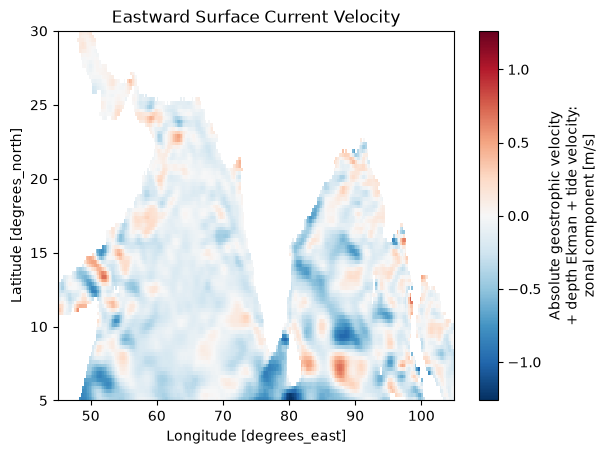

In [11]:
ds_curr["uo"].isel(time=0).plot()

import matplotlib.pyplot as plt
plt.title("Eastward Surface Current Velocity")
plt.show()

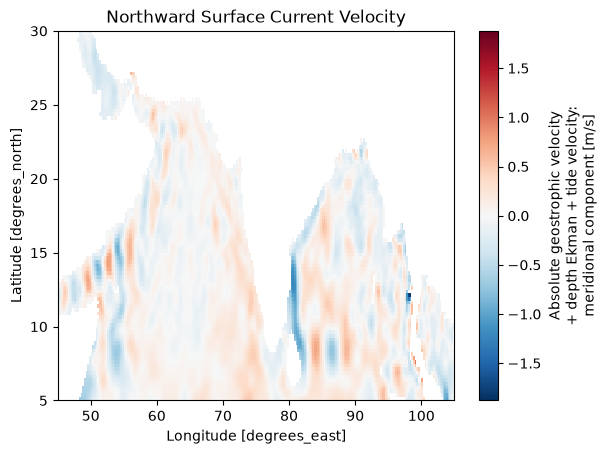

In [12]:
ds_curr["vo"].isel(time=0).plot()

plt.title("Northward Surface Current Velocity")
plt.show()